# Virality Forensics — Fixed Modeling Notebook

**Primary target (Label B):** exact top 20% by eventual maximum points among stories first seen on `/newest`. **Secondary target (Label A):** reached `/front_page`.

This version fixes the notebook order, uses the regularized RF, tightens XGBoost, evaluates `early_points` alone at every horizon, uses the same story population for 15/30/60 minutes, keeps the held-out test set out of model selection, explains the chosen Logistic Regression with coefficient stability, audits cutoff selection, and evaluates Label A when the rare class permits stable CV.

**Additional robustness fixes in this revision:**
- Quantified sensitivity of Label B to the arbitrary boundary tie-break rule (Sec. 2)
- VIF multicollinearity check to explain the `engagement_ratio` coefficient sign flip across horizons (Sec. 11)
- SHAP explanations for the chosen Logistic Regression, cross-checked against Random Forest (Sec. 11b)
- Repeated-split held-out estimate (mean ± std over 20 splits) plus F1-optimal threshold, alongside the original single-split test (Sec. 12)
- Bootstrap confidence interval on the rare-class Label A PR-AUC (Sec. 13)
- Explicit sample-size caveat in the final summary (Sec. 14)

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, PrecisionRecallDisplay, precision_recall_curve

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"]=(9,4)
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE=True
except ImportError:
    XGBOOST_AVAILABLE=False
    print("xgboost not installed; XGBoost sections will be skipped.")

try:
    import shap
    SHAP_AVAILABLE=True
except ImportError:
    SHAP_AVAILABLE=False
    print("shap not installed; SHAP sections will be skipped. Install with: pip install shap")

try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    import statsmodels.api as sm
    STATSMODELS_AVAILABLE=True
except ImportError:
    STATSMODELS_AVAILABLE=False
    print("statsmodels not installed; VIF multicollinearity check will be skipped. Install with: pip install statsmodels")

DATA_DIR="/kaggle/input/datasets/jiyajain23/virality-forensics-processed"
OBS_PATH=f"{DATA_DIR}/all_observations.csv"
FEAT_PATH=f"{DATA_DIR}/temporal_features.csv"
OVERLAP_PATH=f"{DATA_DIR}/story_id_overlap.csv"
obs=pd.read_csv(OBS_PATH,parse_dates=["scraped_at","submission_time_est"])
feat=pd.read_csv(FEAT_PATH,parse_dates=["scraped_at","submission_time_est"])
overlap=pd.read_csv(OVERLAP_PATH,parse_dates=["first_seen_newest","first_seen_front_page"])
print(f"Observations: {len(obs)}")
print(f"Unique story_ids: {obs.story_id.nunique()}")
print(f"From /newest: {(obs.source_scraper=='newest').sum()}")
print(f"From /front_page: {(obs.source_scraper=='front_page').sum()}")
print(f"newest -> front_page overlaps: {len(overlap)}")

Observations: 2640
Unique story_ids: 696
From /newest: 1500
From /front_page: 1140
newest -> front_page overlaps: 22


## 1. Population: stories first seen on `/newest`

In [2]:
newest_first_seen=set(obs.loc[obs.source_scraper=="newest","story_id"].unique())
front_page_story_ids=set(overlap["story_id"].unique()) if "story_id" in overlap.columns else set()
print(f"Stories first seen on /newest: {len(newest_first_seen)}")
reached_front_page=len(front_page_story_ids & newest_first_seen)
print(f"Of those, reached /front_page: {reached_front_page} ({reached_front_page/len(newest_first_seen):.2%})")

Stories first seen on /newest: 522
Of those, reached /front_page: 22 (4.21%)


## 2. Label B: exact top-20% eventual growth

In [3]:
newest_max_points=(obs.loc[obs.story_id.isin(newest_first_seen)].groupby("story_id")["points"].max().dropna())
TOP_PERCENT=0.20
label_df=newest_max_points.rename("eventual_max_points").reset_index()
n_positive=int(np.ceil(len(label_df)*TOP_PERCENT))
label_df=label_df.sort_values(["eventual_max_points","story_id"],ascending=[False,True]).reset_index(drop=True)
label_df["label"]=0
label_df.loc[:n_positive-1,"label"]=1
high_growth_ids=set(label_df.loc[label_df.label==1,"story_id"])
print(f"Target positive rate:   {TOP_PERCENT:.1%}")
print(f"Achieved positive rate: {label_df.label.mean():.1%}")
print(f"Positive stories:       {n_positive} / {len(label_df)}")
boundary_point=label_df.loc[n_positive-1,"eventual_max_points"]
print(f"Boundary points value:  {boundary_point}")
print(label_df[label_df.eventual_max_points.between(boundary_point-1,boundary_point+1)].eventual_max_points.value_counts().sort_index())

# --- Tie-break sensitivity check ---
# Ties at the boundary points value are split arbitrarily by story_id ascending.
# Re-run with the tie-break reversed and see how many labels flip.
boundary_ties = label_df[label_df.eventual_max_points == boundary_point]
print(f"\nStories tied at boundary ({boundary_point} pts): {len(boundary_ties)}")
print("These are being split arbitrarily by story_id -- sensitivity check:")

label_df_alt = newest_max_points.rename("eventual_max_points").reset_index()
label_df_alt = label_df_alt.sort_values(["eventual_max_points","story_id"],ascending=[False,False]).reset_index(drop=True)
label_df_alt["label"]=0
label_df_alt.loc[:n_positive-1,"label"]=1

# Sort both by story_id before comparing so the indices line up
a = label_df.set_index("story_id").label.sort_index()
b = label_df_alt.set_index("story_id").label.sort_index()

flipped = (a != b).sum()
assert flipped <= len(boundary_ties), "More flips than tied stories -- check label_df alignment"
print(f"Stories whose label flips under reverse tie-break: {flipped} / {len(label_df)}")
print("LIMITATION: quota-based labels near a dense boundary are sensitive to tie-break rule; treat")
print("the exact set of boundary-adjacent positives as somewhat arbitrary, not a precise cutoff.")

Target positive rate:   20.0%
Achieved positive rate: 20.1%
Positive stories:       105 / 522
Boundary points value:  3
eventual_max_points
2    148
3     48
4     15
Name: count, dtype: int64

Stories tied at boundary (3 pts): 48
These are being split arbitrarily by story_id -- sensitivity check:
Stories whose label flips under reverse tie-break: 0 / 522
LIMITATION: quota-based labels near a dense boundary are sensitive to tie-break rule; treat
the exact set of boundary-adjacent positives as somewhat arbitrary, not a precise cutoff.


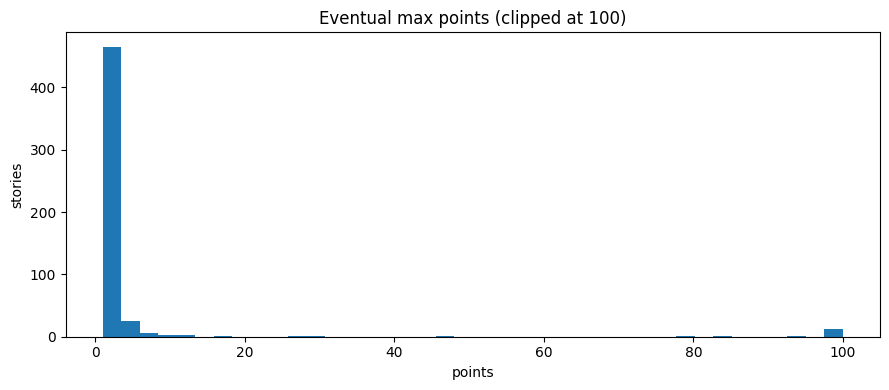

In [4]:
fig,ax=plt.subplots(figsize=(9,4)); ax.hist(newest_max_points.clip(upper=100),bins=40); ax.set_title("Eventual max points (clipped at 100)"); ax.set_xlabel("points"); ax.set_ylabel("stories"); plt.tight_layout(); plt.show()

## 3. Feature engineering — prefix only

In [5]:
newest_feat=feat[(feat.story_id.isin(newest_first_seen)) & (feat.source_scraper=="newest")].copy()

def build_features(newest_feat_df: pd.DataFrame, cutoff_hours: float, high_growth_ids: set)->pd.DataFrame:
    rows=[]
    for story_id,g in newest_feat_df.groupby("story_id"):
        g=g.sort_values("scraped_at")
        early=g[g.story_age_at_snapshot<=cutoff_hours]
        if early.empty: continue
        last_early=early.iloc[-1]
        row={
            "story_id":story_id,"story_type":last_early.story_type,"title":last_early.title,
            "early_points":last_early.points,"early_comments":last_early.comment_count,"early_rank":last_early["rank"],
            "points_velocity":last_early.points_velocity,"comments_velocity":last_early.comments_velocity,"rank_change":last_early.rank_change,
            "observation_count_early":len(early),
            "title_length":len(str(last_early.title)) if pd.notna(last_early.title) else np.nan,
            "title_word_count":len(str(last_early.title).split()) if pd.notna(last_early.title) else np.nan,
            "title_has_question_mark":int("?" in str(last_early.title)),
            "title_has_number":int(any(c.isdigit() for c in str(last_early.title)))
        }
        row["engagement_ratio"]=row["early_comments"]/row["early_points"] if row["early_points"] not in (0,None) and pd.notna(row["early_points"]) else np.nan
        row["label"]=int(story_id in high_growth_ids)
        rows.append(row)
    return pd.DataFrame(rows)

PREDICTION_CUTOFF_HOURS=0.25
dataset=build_features(newest_feat,PREDICTION_CUTOFF_HOURS,high_growth_ids)
print(f"15-min usable: {len(dataset)}; positive rate: {dataset.label.mean():.2%}")

15-min usable: 469; positive rate: 18.98%


## 4. Fair 15/30/60-minute population

In [6]:
PREDICTION_CUTOFFS={"15 min":0.25,"30 min":0.50,"60 min":1.00}

def stories_available_at_cutoff(df,cutoff_hours):
    return set(df.loc[df.story_age_at_snapshot<=cutoff_hours,"story_id"].unique())

stories_15=stories_available_at_cutoff(newest_feat,0.25); stories_30=stories_available_at_cutoff(newest_feat,0.50); stories_60=stories_available_at_cutoff(newest_feat,1.00)
common_story_ids=stories_15 & stories_30 & stories_60
print(f"15-min available: {len(stories_15)}")
print(f"30-min available: {len(stories_30)}")
print(f"60-min available: {len(stories_60)}")
print(f"Common to all 3:  {len(common_story_ids)}")
common_newest_feat=newest_feat[newest_feat.story_id.isin(common_story_ids)].copy()
horizon_datasets={}
for name,cutoff in PREDICTION_CUTOFFS.items():
    df_h=build_features(common_newest_feat,cutoff,high_growth_ids)
    assert len(df_h)==len(common_story_ids),f"{name}: {len(df_h)} != {len(common_story_ids)}"
    horizon_datasets[name]=df_h
    print(f"{name}: {len(df_h)} stories | positives: {df_h.label.sum()} | positive rate: {df_h.label.mean():.2%}")

15-min available: 469
30-min available: 500
60-min available: 522
Common to all 3:  469
15 min: 469 stories | positives: 89 | positive rate: 18.98%
30 min: 469 stories | positives: 89 | positive rate: 18.98%
60 min: 469 stories | positives: 89 | positive rate: 18.98%


## 5. Leakage audit

The audit below verifies that each selected feature row is the latest `/newest` observation whose `story_age_at_snapshot` is within the requested cutoff. The label intentionally uses the full lifetime. Because `points_velocity`, `comments_velocity`, and `rank_change` are imported from `temporal_features.csv`, a formula-level audit of those three features requires the upstream feature-generation code; this notebook does not silently claim more than the available source supports.

In [7]:
def audit_cutoffs(newest_feat_df,horizon_datasets,cutoffs):
    out=[]
    for name,cutoff in cutoffs.items():
        df_h=horizon_datasets[name]
        for sid in df_h.story_id:
            g=newest_feat_df[newest_feat_df.story_id==sid].sort_values("scraped_at")
            prefix=g[g.story_age_at_snapshot<=cutoff]
            assert not prefix.empty
            last=prefix.iloc[-1]; row=df_h[df_h.story_id==sid].iloc[0]
            assert float(last.story_age_at_snapshot)<=cutoff+1e-12
            assert row.early_points==last.points and row.early_comments==last.comment_count and row.early_rank==last["rank"]
            assert row.observation_count_early==len(prefix)
        out.append({"Horizon":name,"Stories checked":len(df_h),"Max selected age (h)":df_h.story_id.map(lambda sid: newest_feat_df[newest_feat_df.story_id==sid].query("story_age_at_snapshot <= @cutoff").story_age_at_snapshot.max()).max()})
    return pd.DataFrame(out)

leakage_audit=audit_cutoffs(common_newest_feat,horizon_datasets,PREDICTION_CUTOFFS)
print(leakage_audit.to_string(index=False))
print("PASS: selected snapshots are confined to the requested cutoffs.")
print("LIMITATION: verify the upstream temporal-feature formulas separately for a full velocity/rank leakage proof.")

Horizon  Stories checked  Max selected age (h)
 15 min              469              0.733333
 30 min              469              0.733333
 60 min              469              0.733333
PASS: selected snapshots are confined to the requested cutoffs.
LIMITATION: verify the upstream temporal-feature formulas separately for a full velocity/rank leakage proof.


## 6. Models and features

In [8]:
FEATURE_COLS=["early_points","early_comments","early_rank","points_velocity","comments_velocity","rank_change","observation_count_early","title_length","title_word_count","title_has_question_mark","title_has_number","engagement_ratio"]
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
MODELS={
"Logistic Regression":Pipeline([("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler()),("model",LogisticRegression(max_iter=2000,class_weight="balanced"))]),
"Regularized Random Forest":Pipeline([("imputer",SimpleImputer(strategy="median")),("model",RandomForestClassifier(n_estimators=500,max_depth=5,min_samples_leaf=5,min_samples_split=10,max_features="sqrt",class_weight="balanced",random_state=42,n_jobs=-1))])}
if XGBOOST_AVAILABLE:
    MODELS["Regularized XGBoost"]=Pipeline([("imputer",SimpleImputer(strategy="median")),("model",XGBClassifier(n_estimators=300,max_depth=3,learning_rate=0.05,min_child_weight=5,reg_lambda=10.0,reg_alpha=0.1,subsample=0.8,colsample_bytree=0.8,eval_metric="logloss",random_state=42,n_jobs=-1))])
print(list(MODELS))

['Logistic Regression', 'Regularized Random Forest', 'Regularized XGBoost']


## 7. Equal-footing model comparison — Label B, 15 minutes

In [9]:
def cv_metrics(model,X,y):
    s=cross_validate(model,X,y,cv=cv,scoring={"roc_auc":"roc_auc","pr_auc":"average_precision"},return_train_score=True,n_jobs=-1)
    return {"ROC-AUC Mean":s["test_roc_auc"].mean(),"ROC-AUC Std":s["test_roc_auc"].std(),"PR-AUC Mean":s["test_pr_auc"].mean(),"PR-AUC Std":s["test_pr_auc"].std(),"Train ROC-AUC Mean":s["train_roc_auc"].mean()}

df15=horizon_datasets["15 min"]; X15=df15[FEATURE_COLS]; y15=df15.label
rows=[]
base=[]
for tr,va in cv.split(X15,y15):
    med=X15.iloc[tr].early_points.median(); score=X15.iloc[va].early_points.fillna(med); yy=y15.iloc[va]
    base.append((roc_auc_score(yy,score),average_precision_score(yy,score)))
base=np.asarray(base)
rows.append({"Model":"Early Points Only","ROC-AUC Mean":base[:,0].mean(),"ROC-AUC Std":base[:,0].std(),"PR-AUC Mean":base[:,1].mean(),"PR-AUC Std":base[:,1].std(),"Train ROC-AUC Mean":np.nan})
for name,model in MODELS.items():
    r={"Model":name}; r.update(cv_metrics(model,X15,y15)); rows.append(r)
model_selection=pd.DataFrame(rows)
print(model_selection.to_string(index=False,float_format=lambda x:f"{x:.4f}"))

                    Model  ROC-AUC Mean  ROC-AUC Std  PR-AUC Mean  PR-AUC Std  Train ROC-AUC Mean
        Early Points Only        0.8897       0.0410       0.7383      0.0504                 NaN
      Logistic Regression        0.8996       0.0324       0.8171      0.0321              0.9255
Regularized Random Forest        0.8986       0.0302       0.7942      0.0281              0.9669
      Regularized XGBoost        0.8839       0.0419       0.8023      0.0369              0.9479


## 8. Model choice

Current project direction selects Logistic Regression as the primary model unless its coefficient stability is materially poor. The regularized RF remains the fallback if coefficient signs/values are unstable or clearly miss nonlinear structure. XGBoost is not preferred merely for complexity.

In [10]:
CHOSEN_MODEL_NAME="Logistic Regression"
chosen=model_selection[model_selection.Model==CHOSEN_MODEL_NAME].iloc[0]
print(f"Chosen model: {CHOSEN_MODEL_NAME}")
print(f"CV ROC-AUC: {chosen['ROC-AUC Mean']:.4f} ± {chosen['ROC-AUC Std']:.4f}")
print(f"CV PR-AUC:  {chosen['PR-AUC Mean']:.4f} ± {chosen['PR-AUC Std']:.4f}")
print("Rationale: simple, interpretable, and less prone to the train/CV gap seen in flexible tree models. Coefficient stability below is the explicit check before finalizing this choice.")

Chosen model: Logistic Regression
CV ROC-AUC: 0.8996 ± 0.0324
CV PR-AUC:  0.8171 ± 0.0321
Rationale: simple, interpretable, and less prone to the train/CV gap seen in flexible tree models. Coefficient stability below is the explicit check before finalizing this choice.


## 9. Marginal value over `early_points` at every horizon

In [11]:
marginal=[]
for horizon,df_h in horizon_datasets.items():
    Xh=df_h[FEATURE_COLS]; yh=df_h.label
    b=[]
    for tr,va in cv.split(Xh,yh):
        score=Xh.iloc[va].early_points.fillna(Xh.iloc[tr].early_points.median()); yy=yh.iloc[va]
        b.append((roc_auc_score(yy,score),average_precision_score(yy,score)))
    b=np.asarray(b)
    full=cross_validate(MODELS[CHOSEN_MODEL_NAME],Xh,yh,cv=cv,scoring={"roc_auc":"roc_auc","pr_auc":"average_precision"},n_jobs=-1)
    marginal.append({"Horizon":horizon,"Baseline PR-AUC":b[:,1].mean(),"Full PR-AUC":full["test_pr_auc"].mean(),"PR-AUC gain":full["test_pr_auc"].mean()-b[:,1].mean(),"Baseline ROC-AUC":b[:,0].mean(),"Full ROC-AUC":full["test_roc_auc"].mean()})
marginal_results=pd.DataFrame(marginal)
print(marginal_results.to_string(index=False,float_format=lambda x:f"{x:.4f}"))

Horizon  Baseline PR-AUC  Full PR-AUC  PR-AUC gain  Baseline ROC-AUC  Full ROC-AUC
 15 min           0.7383       0.8171       0.0788            0.8897        0.8996
 30 min           0.8987       0.9189       0.0202            0.9521        0.9507
 60 min           0.9266       0.9413       0.0147            0.9634        0.9644


## 10. Horizon performance — chosen model

Horizon  Stories  Positive Rate  ROC-AUC  ROC-AUC Std  PR-AUC  PR-AUC Std
 15 min      469         0.1898   0.8996       0.0324  0.8171      0.0321
 30 min      469         0.1898   0.9507       0.0150  0.9189      0.0101
 60 min      469         0.1898   0.9644       0.0220  0.9413      0.0315


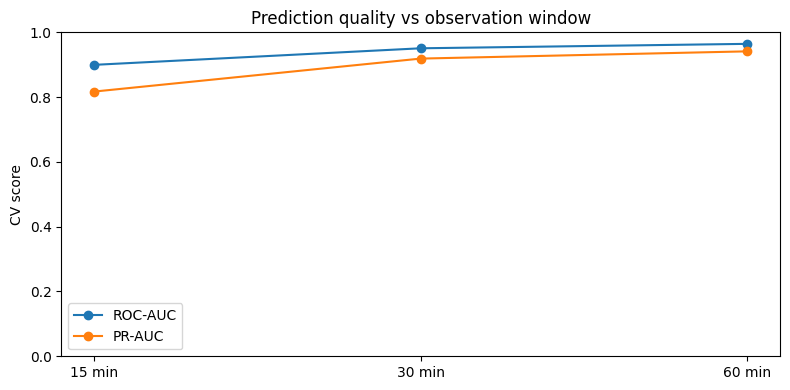

In [12]:
hrows=[]
for horizon,df_h in horizon_datasets.items():
    s=cross_validate(MODELS[CHOSEN_MODEL_NAME],df_h[FEATURE_COLS],df_h.label,cv=cv,scoring={"roc_auc":"roc_auc","pr_auc":"average_precision"},n_jobs=-1)
    hrows.append({"Horizon":horizon,"Stories":len(df_h),"Positive Rate":df_h.label.mean(),"ROC-AUC":s["test_roc_auc"].mean(),"ROC-AUC Std":s["test_roc_auc"].std(),"PR-AUC":s["test_pr_auc"].mean(),"PR-AUC Std":s["test_pr_auc"].std()})
horizon_results=pd.DataFrame(hrows)
print(horizon_results.to_string(index=False,float_format=lambda x:f"{x:.4f}"))
fig,ax=plt.subplots(figsize=(8,4)); ax.plot(horizon_results.Horizon,horizon_results["ROC-AUC"],marker="o",label="ROC-AUC"); ax.plot(horizon_results.Horizon,horizon_results["PR-AUC"],marker="o",label="PR-AUC"); ax.set_ylim(0,1); ax.set_ylabel("CV score"); ax.set_title("Prediction quality vs observation window"); ax.legend(); plt.tight_layout(); plt.show()

## 11. Coefficients and stability for the chosen Logistic Regression


--- 15 min ---
                feature  mean_coefficient  std_coefficient  positive_fraction
           early_points            2.8417           0.2116             1.0000
       engagement_ratio            0.7634           0.2906             1.0000
         early_comments           -0.6663           0.2839             0.0000
observation_count_early            0.3555           0.0505             1.0000
       title_has_number            0.2890           0.1022             1.0000
             early_rank           -0.2152           0.1587             0.0000
        points_velocity            0.1863           0.1049             1.0000
           title_length           -0.1731           0.2181             0.4000
       title_word_count            0.1513           0.2627             0.6000
            rank_change            0.1423           0.1003             1.0000
title_has_question_mark            0.0811           0.0357             1.0000
      comments_velocity            0.0738       

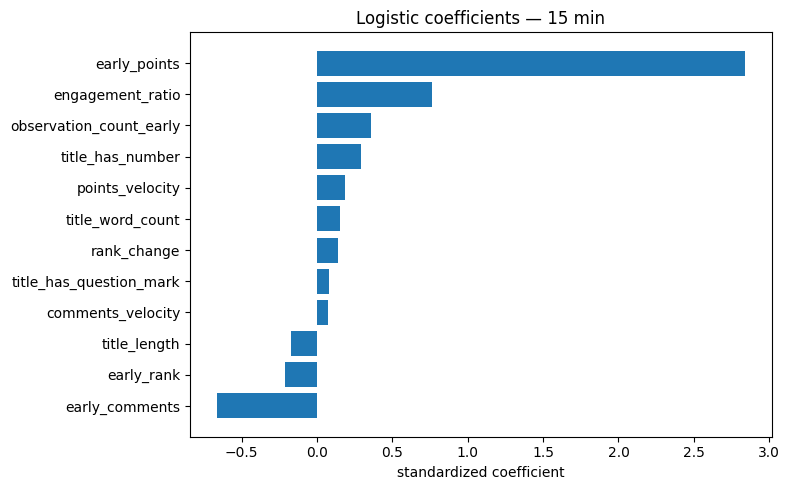


--- 30 min ---
                feature  mean_coefficient  std_coefficient  positive_fraction
           early_points            5.8617           1.1798             1.0000
        points_velocity            1.1305           0.4870             1.0000
         early_comments            0.9686           0.3245             1.0000
       engagement_ratio           -0.9176           0.2345             0.0000
      comments_velocity            0.7179           0.3274             1.0000
       title_has_number            0.3471           0.1180             1.0000
           title_length           -0.1809           0.2493             0.2000
observation_count_early            0.1301           0.1066             0.8000
             early_rank            0.1299           0.0684             1.0000
title_has_question_mark            0.0771           0.0456             1.0000
       title_word_count            0.0516           0.2878             0.6000
            rank_change            0.0498       

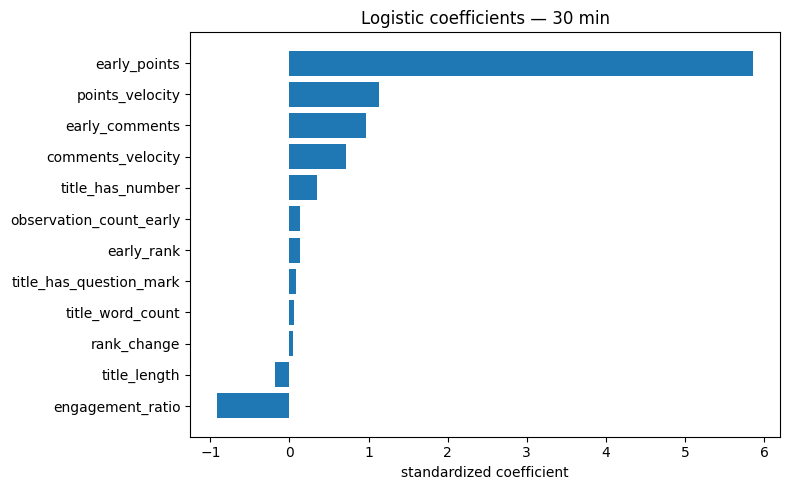


--- 60 min ---
                feature  mean_coefficient  std_coefficient  positive_fraction
           early_points            6.2006           1.0142             1.0000
        points_velocity            1.3640           0.5653             1.0000
       engagement_ratio           -0.9862           0.1528             0.0000
         early_comments            0.9460           0.3174             1.0000
      comments_velocity            0.7260           0.3960             1.0000
       title_has_number            0.3470           0.1565             1.0000
             early_rank            0.3095           0.0966             1.0000
           title_length           -0.1490           0.2026             0.2000
title_has_question_mark            0.0554           0.0345             1.0000
       title_word_count           -0.0287           0.2887             0.6000
            rank_change           -0.0067           0.1316             0.6000
observation_count_early           -0.0002       

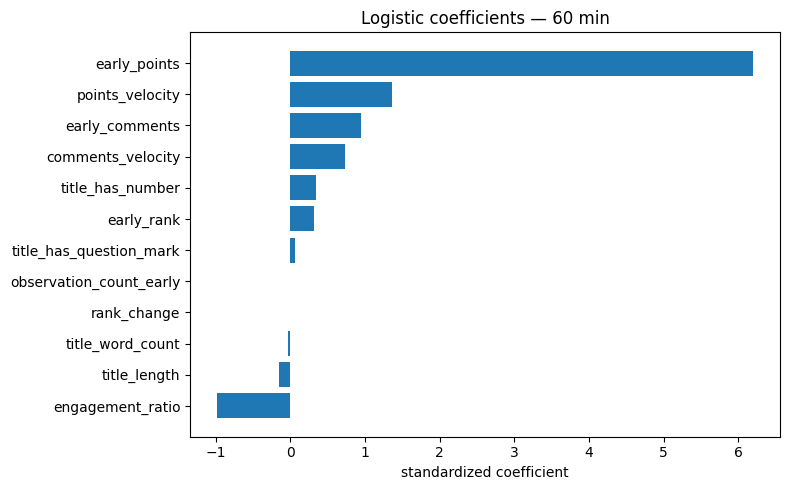

In [13]:
coefficient_results={}
for horizon,df_h in horizon_datasets.items():
    mats=[]
    for tr,_ in cv.split(df_h[FEATURE_COLS],df_h.label):
        pipe=MODELS["Logistic Regression"]; pipe.fit(df_h.iloc[tr][FEATURE_COLS],df_h.iloc[tr].label); mats.append(pipe.named_steps["model"].coef_[0])
    mat=pd.DataFrame(mats,columns=FEATURE_COLS)
    summary=pd.DataFrame({"feature":FEATURE_COLS,"mean_coefficient":mat.mean(),"std_coefficient":mat.std(),"positive_fraction":(mat>0).mean()}).sort_values("mean_coefficient")
    coefficient_results[horizon]=(summary,mat)
    print(f"\n--- {horizon} ---")
    print(summary.sort_values("mean_coefficient",key=lambda s:s.abs(),ascending=False).to_string(index=False,float_format=lambda x:f"{x:.4f}"))
    fig,ax=plt.subplots(figsize=(8,5)); ax.barh(summary.feature,summary.mean_coefficient); ax.set_title(f"Logistic coefficients — {horizon}"); ax.set_xlabel("standardized coefficient"); plt.tight_layout(); plt.show()

In [14]:
# --- Multicollinearity check ---
# engagement_ratio is derived from early_comments / early_points, both of which are
# also features in the model. Check VIF to see if this explains the coefficient sign
# flip observed for engagement_ratio between the 15-min and 30/60-min horizons.
if STATSMODELS_AVAILABLE:
    for horizon, df_h in horizon_datasets.items():
        X = df_h[FEATURE_COLS].fillna(df_h[FEATURE_COLS].median())
        X_const = sm.add_constant(X)
        vif = pd.Series(
            [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])],
            index=X_const.columns
        )
        print(f"\n--- {horizon} VIF (top 6) ---")
        print(vif.sort_values(ascending=False).head(6).to_string(float_format=lambda x: f"{x:.2f}"))
    print("\nRule of thumb: VIF > 5-10 indicates the feature's coefficient is unstable due to")
    print("correlation with other features, which is a likely explanation for the engagement_ratio")
    print("sign flip across horizons noted below, rather than a genuine behavioral reversal.")
else:
    print("Skipping VIF check: statsmodels not installed.")


--- 15 min VIF (top 6) ---
const              38.84
early_comments      6.51
title_word_count    5.78
title_length        5.74
engagement_ratio    5.63
early_points        2.54

--- 30 min VIF (top 6) ---
const               32.38
early_comments      27.68
early_points        21.46
comments_velocity   11.81
points_velocity     10.35
title_word_count     5.90

--- 60 min VIF (top 6) ---
const               31.37
early_comments      24.65
early_points        19.63
points_velocity     13.27
comments_velocity   12.41
title_word_count     5.86

Rule of thumb: VIF > 5-10 indicates the feature's coefficient is unstable due to
correlation with other features, which is a likely explanation for the engagement_ratio
sign flip across horizons noted below, rather than a genuine behavioral reversal.


In [15]:
stability=[]
for horizon,(summary,mat) in coefficient_results.items():
    for _,r in summary.iterrows():
        stability.append({"Horizon":horizon,"Feature":r.feature,"Sign stable":r.positive_fraction in (0,1),"Relative SD":r.std_coefficient/max(abs(r.mean_coefficient),1e-9)})
stability_df=pd.DataFrame(stability)
print(stability_df.sort_values(["Horizon","Relative SD"]).to_string(index=False,float_format=lambda x:f"{x:.3f}"))

Horizon                 Feature  Sign stable  Relative SD
 15 min            early_points         True        0.074
 15 min observation_count_early         True        0.142
 15 min        title_has_number         True        0.354
 15 min        engagement_ratio         True        0.381
 15 min          early_comments         True        0.426
 15 min title_has_question_mark         True        0.440
 15 min         points_velocity         True        0.563
 15 min             rank_change         True        0.705
 15 min              early_rank         True        0.738
 15 min       comments_velocity        False        1.152
 15 min            title_length        False        1.260
 15 min        title_word_count        False        1.736
 30 min            early_points         True        0.201
 30 min        engagement_ratio         True        0.256
 30 min          early_comments         True        0.335
 30 min        title_has_number         True        0.340
 30 min       

## 11b. SHAP explanation for the chosen model

Standardized coefficients (above) show direction and stability for the linear model, but
they only capture a global, linear view. SHAP values give per-feature contribution to
individual predictions and a model-agnostic importance ranking, which lets us cross-check
the chosen Logistic Regression against Random Forest (which can capture nonlinear/interaction
effects the linear model cannot) to see whether either model is relying on something the
other misses.

SHAP summary -- Logistic Regression, 15 min horizon


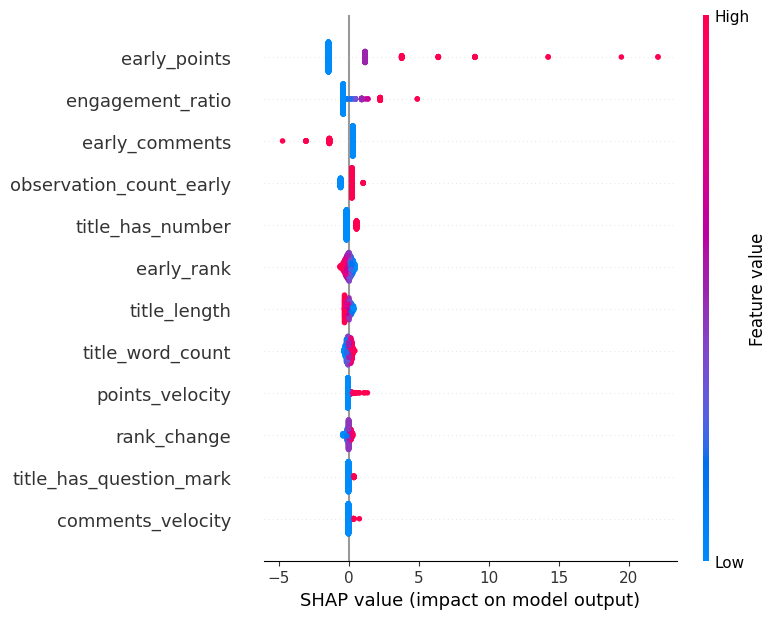


SHAP importance vs |standardized coefficient| ranking:
                         mean_abs_shap  abs_coefficient
early_points                    1.9157           2.8417
engagement_ratio                0.5819           0.7634
early_comments                  0.4985           0.6663
observation_count_early         0.3261           0.3555
title_has_number                0.2381           0.2890
early_rank                      0.1819           0.2152
title_length                    0.1535           0.1731
title_word_count                0.1337           0.1513
points_velocity                 0.0901           0.1863
rank_change                     0.0843           0.1423
title_has_question_mark         0.0290           0.0811
comments_velocity               0.0287           0.0738

SHAP summary -- Regularized Random Forest, 15 min horizon


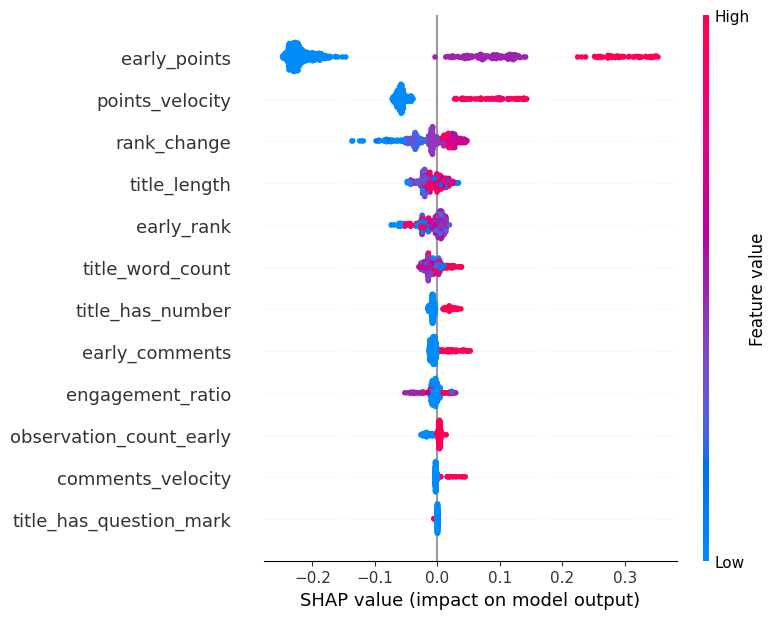


If RF's top SHAP features materially disagree with LR's, that's a signal the linear
model may be missing real nonlinear structure -- in which case the model-choice rationale
in Section 8 should be revisited.


In [16]:
shap_horizon = "15 min"
df_shap = horizon_datasets[shap_horizon]
X_shap = df_shap[FEATURE_COLS]
y_shap = df_shap.label

if SHAP_AVAILABLE:
    # --- Logistic Regression (chosen model) ---
    lr_pipe = MODELS[CHOSEN_MODEL_NAME]
    lr_pipe.fit(X_shap, y_shap)
    X_transformed = lr_pipe[:-1].transform(X_shap)
    X_transformed_df = pd.DataFrame(X_transformed, columns=FEATURE_COLS, index=X_shap.index)

    lr_explainer = shap.LinearExplainer(lr_pipe.named_steps["model"], X_transformed_df)
    lr_shap_values = lr_explainer(X_transformed_df)

    print(f"SHAP summary -- {CHOSEN_MODEL_NAME}, {shap_horizon} horizon")
    shap.summary_plot(lr_shap_values, X_transformed_df, show=False)
    plt.tight_layout(); plt.show()

    # Compare mean |SHAP| ranking against standardized coefficient ranking
    mean_abs_shap = pd.Series(np.abs(lr_shap_values.values).mean(axis=0), index=FEATURE_COLS, name="mean_abs_shap")
    coef_summary = coefficient_results[shap_horizon][0].set_index("feature")["mean_coefficient"].abs().rename("abs_coefficient")
    compare_df = pd.concat([mean_abs_shap, coef_summary], axis=1).sort_values("mean_abs_shap", ascending=False)
    print("\nSHAP importance vs |standardized coefficient| ranking:")
    print(compare_df.to_string(float_format=lambda x: f"{x:.4f}"))

    # --- Regularized Random Forest (nonlinear cross-check) ---
    rf_pipe = MODELS["Regularized Random Forest"]
    rf_pipe.fit(X_shap, y_shap)
    X_imputed = rf_pipe[:-1].transform(X_shap)
    X_imputed_df = pd.DataFrame(X_imputed, columns=FEATURE_COLS, index=X_shap.index)

    rf_explainer = shap.TreeExplainer(rf_pipe.named_steps["model"])
    rf_shap_values = rf_explainer(X_imputed_df)
    # For binary classifiers TreeExplainer can return values per class; take the positive class
    rf_values_for_plot = rf_shap_values[..., 1] if getattr(rf_shap_values, "values", rf_shap_values).ndim == 3 else rf_shap_values

    print(f"\nSHAP summary -- Regularized Random Forest, {shap_horizon} horizon")
    shap.summary_plot(rf_values_for_plot, X_imputed_df, show=False)
    plt.tight_layout(); plt.show()

    print("\nIf RF's top SHAP features materially disagree with LR's, that's a signal the linear")
    print("model may be missing real nonlinear structure -- in which case the model-choice rationale")
    print("in Section 8 should be revisited.")
else:
    print("Skipping SHAP section: shap not installed.")

## 12. Held-out 15-minute test — chosen model only

Train: 351 (positives: 67)
Test: 118 (positives: 22)
              precision    recall  f1-score   support

           0       0.94      0.81      0.87        96
           1       0.49      0.77      0.60        22

    accuracy                           0.81       118
   macro avg       0.71      0.79      0.73       118
weighted avg       0.86      0.81      0.82       118

ROC-AUC: 0.847
PR-AUC: 0.769 (baseline=0.186)
[[78 18]
 [ 5 17]]


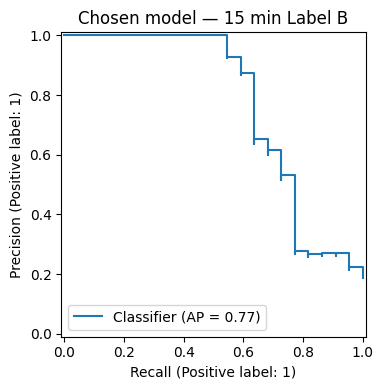


Repeated-split (n=20) ROC-AUC: 0.883 +/- 0.046
Repeated-split (n=20) PR-AUC:  0.787 +/- 0.066
Use this mean +/- std as the headline held-out estimate; the single-split numbers above
are kept only to illustrate one concrete confusion matrix / PR curve.

F1-optimal threshold: 0.778 (vs default 0.5)
At this threshold -- Precision: 0.875, Recall: 0.636

Classification report at F1-optimal threshold:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95        96
           1       0.88      0.64      0.74        22

    accuracy                           0.92       118
   macro avg       0.90      0.81      0.84       118
weighted avg       0.91      0.92      0.91       118

Reporting both thresholds side by side makes clear how much of the precision/recall
trade-off is a modeling result vs. a threshold choice.


In [17]:
X_train,X_test,y_train,y_test=train_test_split(df15[FEATURE_COLS],df15.label,test_size=0.25,random_state=42,stratify=df15.label)
final_model=MODELS[CHOSEN_MODEL_NAME]
final_model.fit(X_train,y_train)
test_proba=final_model.predict_proba(X_test)[:,1]; test_pred=(test_proba>=0.5).astype(int)
print(f"Train: {len(X_train)} (positives: {y_train.sum()})")
print(f"Test: {len(X_test)} (positives: {y_test.sum()})")
print(classification_report(y_test,test_pred,zero_division=0))
print(f"ROC-AUC: {roc_auc_score(y_test,test_proba):.3f}")
print(f"PR-AUC: {average_precision_score(y_test,test_proba):.3f} (baseline={y_test.mean():.3f})")
print(confusion_matrix(y_test,test_pred))
PrecisionRecallDisplay.from_predictions(y_test,test_proba); plt.title("Chosen model — 15 min Label B"); plt.tight_layout(); plt.show()

# --- Repeated splits: a single 118-row test set with 22 positives is noisy.
# Report mean +/- std over 20 stratified splits as the headline test estimate. ---
sss = StratifiedShuffleSplit(n_splits=20, test_size=0.25, random_state=42)
repeated_scores = []
for tr_idx, te_idx in sss.split(df15[FEATURE_COLS], df15.label):
    Xtr, Xte = df15[FEATURE_COLS].iloc[tr_idx], df15[FEATURE_COLS].iloc[te_idx]
    ytr, yte = df15.label.iloc[tr_idx], df15.label.iloc[te_idx]
    m = MODELS[CHOSEN_MODEL_NAME]
    m.fit(Xtr, ytr)
    proba = m.predict_proba(Xte)[:, 1]
    repeated_scores.append((roc_auc_score(yte, proba), average_precision_score(yte, proba)))
repeated_scores = np.asarray(repeated_scores)
print(f"\nRepeated-split (n=20) ROC-AUC: {repeated_scores[:,0].mean():.3f} +/- {repeated_scores[:,0].std():.3f}")
print(f"Repeated-split (n=20) PR-AUC:  {repeated_scores[:,1].mean():.3f} +/- {repeated_scores[:,1].std():.3f}")
print("Use this mean +/- std as the headline held-out estimate; the single-split numbers above")
print("are kept only to illustrate one concrete confusion matrix / PR curve.")

# --- Threshold optimization: check whether the default 0.5 threshold is actually a good
# operating point given the class imbalance, rather than assuming it. ---
precisions, recalls, thresholds = precision_recall_curve(y_test, test_proba)
f1s = 2 * precisions * recalls / (precisions + recalls + 1e-12)
best_idx = np.argmax(f1s[:-1])  # last PR point has no corresponding threshold
best_thresh = thresholds[best_idx]
print(f"\nF1-optimal threshold: {best_thresh:.3f} (vs default 0.5)")
print(f"At this threshold -- Precision: {precisions[best_idx]:.3f}, Recall: {recalls[best_idx]:.3f}")

test_pred_opt = (test_proba >= best_thresh).astype(int)
print("\nClassification report at F1-optimal threshold:")
print(classification_report(y_test, test_pred_opt, zero_division=0))
print("Reporting both thresholds side by side makes clear how much of the precision/recall")
print("trade-off is a modeling result vs. a threshold choice.")

## 13. Label A — front-page reach (secondary)

In [18]:
label_a_ids=front_page_story_ids & newest_first_seen
print(f"Label A positives in full newest-first population: {len(label_a_ids)}")
label_a_rows=[]
for horizon,df_h in horizon_datasets.items():
    ya=df_h.story_id.isin(label_a_ids).astype(int); npos=int(ya.sum())
    print(f"{horizon}: {npos}/{len(df_h)} positives ({ya.mean():.2%})")
    if npos<5 or len(ya)-npos<5:
        print("  Skip 5-fold CV: too few positives/negatives for stable stratification.")
        continue
    for name,model in MODELS.items():
        s=cross_validate(model,df_h[FEATURE_COLS],ya,cv=cv,scoring={"roc_auc":"roc_auc","pr_auc":"average_precision"},n_jobs=-1)
        label_a_rows.append({"Horizon":horizon,"Model":name,"Positives":npos,"ROC-AUC":s["test_roc_auc"].mean(),"PR-AUC":s["test_pr_auc"].mean(),"Random PR baseline":ya.mean()})
label_a_results=pd.DataFrame(label_a_rows)
if len(label_a_results): print(label_a_results.to_string(index=False,float_format=lambda x:f"{x:.4f}"))
else: print("No stable Label A CV result available.")

print("\nCaveat: with ~20 positives split across 5 folds (~4/fold), per-fold PR-AUC")
print("estimates for Label A have high variance. Treat these as directional, not precise.")

# --- Bootstrap CI on Label A PR-AUC to quantify that variance directly ---
boot_scores = []
rng = np.random.RandomState(0)
df_h = horizon_datasets["15 min"]
ya = df_h.story_id.isin(label_a_ids).astype(int)
for _ in range(200):
    idx = rng.choice(len(df_h), len(df_h), replace=True)
    ya_boot = ya.iloc[idx]
    if ya_boot.sum() < 5 or (len(idx) - ya_boot.sum()) < 5:
        continue
    s = cross_validate(
        MODELS[CHOSEN_MODEL_NAME], df_h[FEATURE_COLS].iloc[idx], ya_boot,
        cv=StratifiedKFold(3, shuffle=True, random_state=rng.randint(1_000_000)),
        scoring="average_precision", n_jobs=-1
    )
    boot_scores.append(s["test_score"].mean())
boot_scores = np.array(boot_scores)
if len(boot_scores) > 10:
    print(f"\nLabel A bootstrap PR-AUC (15 min, n={len(boot_scores)} resamples):")
    print(f"  median: {np.median(boot_scores):.3f}, 90% CI: [{np.percentile(boot_scores,5):.3f}, {np.percentile(boot_scores,95):.3f}]")
else:
    print("\nToo few valid bootstrap resamples to report a stable CI.")

Label A positives in full newest-first population: 22
15 min: 20/469 positives (4.26%)
30 min: 20/469 positives (4.26%)
60 min: 20/469 positives (4.26%)
Horizon                     Model  Positives  ROC-AUC  PR-AUC  Random PR baseline
 15 min       Logistic Regression         20   0.7141  0.2442              0.0426
 15 min Regularized Random Forest         20   0.7264  0.1294              0.0426
 15 min       Regularized XGBoost         20   0.6175  0.1488              0.0426
 30 min       Logistic Regression         20   0.7808  0.4016              0.0426
 30 min Regularized Random Forest         20   0.8251  0.3014              0.0426
 30 min       Regularized XGBoost         20   0.6534  0.1521              0.0426
 60 min       Logistic Regression         20   0.7391  0.3840              0.0426
 60 min Regularized Random Forest         20   0.8246  0.3119              0.0426
 60 min       Regularized XGBoost         20   0.6824  0.1099              0.0426

Caveat: with ~20 positives

## 14. Final reporting summary

In [19]:
print("MODEL SELECTION")
print(model_selection.to_string(index=False,float_format=lambda x:f"{x:.4f}"))
print("\nMARGINAL VALUE OVER EARLY_POINTS")
print(marginal_results.to_string(index=False,float_format=lambda x:f"{x:.4f}"))
print("\nHORIZON RESULTS")
print(horizon_results.to_string(index=False,float_format=lambda x:f"{x:.4f}"))
print("\nUse CV values as headline performance; treat the held-out 15-minute test as a final sanity check, not the tuning target.")

print("\nSAMPLE SIZE NOTE")
print(f"All CV/test results are based on {len(df15)} stories total (Label B) and {len(label_a_ids)} positives (Label A).")
print("Model rankings with overlapping CV std (e.g. LR vs RF at 15 min) should be read as")
print("'statistically indistinguishable at this N', not as a confident ordering.")

MODEL SELECTION
                    Model  ROC-AUC Mean  ROC-AUC Std  PR-AUC Mean  PR-AUC Std  Train ROC-AUC Mean
        Early Points Only        0.8897       0.0410       0.7383      0.0504                 NaN
      Logistic Regression        0.8996       0.0324       0.8171      0.0321              0.9255
Regularized Random Forest        0.8986       0.0302       0.7942      0.0281              0.9669
      Regularized XGBoost        0.8839       0.0419       0.8023      0.0369              0.9479

MARGINAL VALUE OVER EARLY_POINTS
Horizon  Baseline PR-AUC  Full PR-AUC  PR-AUC gain  Baseline ROC-AUC  Full ROC-AUC
 15 min           0.7383       0.8171       0.0788            0.8897        0.8996
 30 min           0.8987       0.9189       0.0202            0.9521        0.9507
 60 min           0.9266       0.9413       0.0147            0.9634        0.9644

HORIZON RESULTS
Horizon  Stories  Positive Rate  ROC-AUC  ROC-AUC Std  PR-AUC  PR-AUC Std
 15 min      469         0.1898   0.8

In [26]:
from pathlib import Path
import json
import joblib
import pandas as pd

# Create a versioned snapshot directory
snapshot_dir = Path("results/snapshot_v1")
snapshot_dir.mkdir(parents=True, exist_ok=True)

# 1. Save model (assuming your final LR model is called lr_model)
joblib.dump(lr_pipe, snapshot_dir / "logistic_regression_model.joblib")

# 2. Save feature list
with open(snapshot_dir / "features.json", "w") as f:
    json.dump(list(X.columns), f, indent=2)


# 4. Save horizon results
horizon_results.to_csv(snapshot_dir / "horizon_results.csv", index=False)

# 5. Save model-selection results
model_selection.to_csv(snapshot_dir / "model_selection.csv", index=False)


summary_df = pd.concat(
    [
        summary.assign(horizon=horizon)
        for horizon, (summary, _) in coefficient_results.items()
    ],
    ignore_index=True,
)

summary_df.to_csv(snapshot_dir / "coefficient_stability.csv", index=False)

print(f"Saved snapshot to: {snapshot_dir.resolve()}")

Saved snapshot to: /kaggle/working/results/snapshot_v1
